# SQL Risk Exploration

Using SQLite to run the kind of segment-level queries you'd normally start with when reviewing a credit portfolio.


In [1]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "credit_risk_model_table.csv")
connection = sqlite3.connect(":memory:")
df.to_sql("customer_risk_table", connection, index=False, if_exists="replace")


3200

In [2]:
query = '''
SELECT
    credit_limit_band,
    COUNT(*) AS customers,
    ROUND(AVG(default_next_month), 3) AS observed_default_rate,
    ROUND(AVG(limit_balance), 0) AS average_limit
FROM customer_risk_table
GROUP BY credit_limit_band
ORDER BY observed_default_rate DESC
'''

limit_segments = pd.read_sql_query(query, connection)
limit_segments


,credit_limit_band,customers,observed_default_rate,average_limit
0,very_low,138,0.181,24703.0
1,low,1250,0.162,51777.0
2,medium,1141,0.124,92045.0
3,high,490,0.084,144427.0
4,very_high,181,0.061,218155.0


In [3]:
query = '''
SELECT
    months_with_delay,
    COUNT(*) AS customers,
    ROUND(AVG(default_next_month), 3) AS observed_default_rate,
    ROUND(AVG(utilization_ratio), 3) AS average_utilization
FROM customer_risk_table
GROUP BY months_with_delay
ORDER BY months_with_delay
'''

delay_segments = pd.read_sql_query(query, connection)
delay_segments


,months_with_delay,customers,observed_default_rate,average_utilization
0,0,934,0.025,0.297
1,1,1007,0.076,0.416
2,2,735,0.163,0.512
3,3,365,0.301,0.594
4,4,130,0.538,0.669
5,5,24,0.667,0.759
6,6,5,1.000,0.752


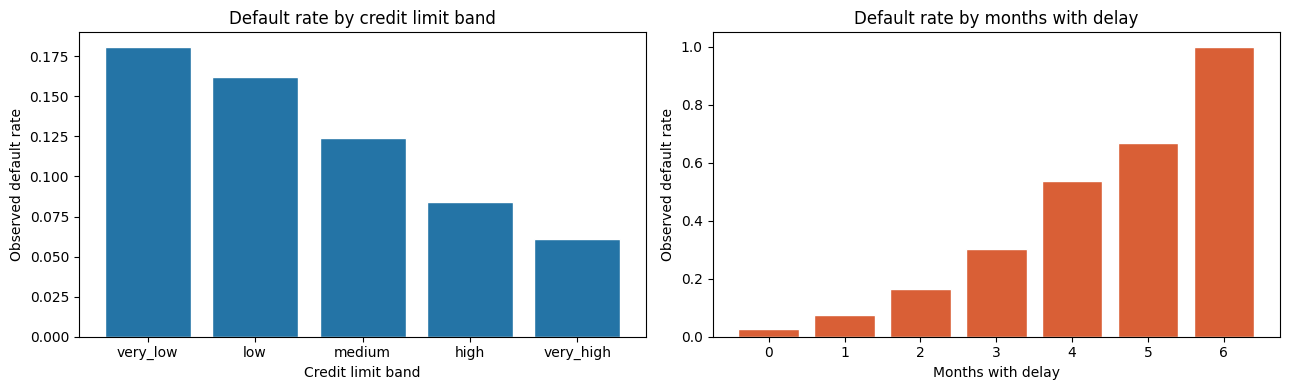

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    limit_segments["credit_limit_band"],
    limit_segments["observed_default_rate"],
    color="#2474a6", edgecolor="white",
)
axes[0].set_title("Default rate by credit limit band")
axes[0].set_ylabel("Observed default rate")
axes[0].set_xlabel("Credit limit band")

axes[1].bar(
    delay_segments["months_with_delay"].astype(str),
    delay_segments["observed_default_rate"],
    color="#d95f36", edgecolor="white",
)
axes[1].set_title("Default rate by months with delay")
axes[1].set_ylabel("Observed default rate")
axes[1].set_xlabel("Months with delay")

plt.tight_layout()
plt.show()


Customers with more months of delay default at much higher rates. This is not surprising, but it is good to confirm before modelling. The credit limit band relationship is less monotonic, which probably reflects confounding with income.
